# Sensitivity Study (Model Parameters)

This notebook builds a compact sensitivity analysis for the project report with a compute budget designed to stay below ~6 hours.

## What this notebook does
- Trains **one** RL policy (`var` objective, gamma-only setup, constant vol).
- Evaluates three strategies on a parameter grid:
  - `Delta-Neutral`
  - `Delta-Gamma-Neutral`
  - `RL (trained baseline)`
- Generates **3 report-ready plots**:
  1. VaR95 heatmaps for all three strategies.
  2. RL improvement heatmaps vs benchmarks.
  3. RL hedge behavior lines (gamma hedge ratio + mean transaction cost) vs `kappa`.

## Important
- This notebook is **independent** from `main.ipynb`.
- It does not modify training artifacts in `main.ipynb`.



In [23]:
import os
import csv
import copy

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch

from C_trading_environment import init_env
from G_parallel_evaluation import evaluate_policy_parallel
from H_parallel_training import train_jobs_parallel



In [24]:
# ------------------------------
# Compute-budget controls
# ------------------------------
# Keep this profile for ~report iteration (target: under ~6h on typical CPU laptop).

N_EPISODES_RL = 100     # RL training episodes (single agent: var)
N_EVAL = 2000          # episodes per grid point and strategy

SIGMA_GRID = [0.20, 0.30, 0.40]
KAPPA_GRID = [0.005, 0.010, 0.020]

SEED_BASE = 2026
EVAL_SEEDS = [300_000 + i for i in range(N_EVAL)]

EVAL_MAX_WORKERS = max(1, (os.cpu_count() or 2) - 1)
TRAIN_MAX_WORKERS = 1   # one RL agent only; keep deterministic and memory-safe

print(f"N_EPISODES_RL={N_EPISODES_RL}, N_EVAL={N_EVAL}")
print(f"grid size={len(SIGMA_GRID)}x{len(KAPPA_GRID)} = {len(SIGMA_GRID)*len(KAPPA_GRID)} points")
print(f"workers: train={TRAIN_MAX_WORKERS}, eval={EVAL_MAX_WORKERS}")



N_EPISODES_RL=100, N_EVAL=2000
grid size=3x3 = 9 points
workers: train=1, eval=15


In [25]:
def make_config(sigma0=0.30, kappa=0.01, v=0.0, rho=0.0, gamma_only_state=True):
    state_dim = 3 if bool(gamma_only_state) else 5
    return {
        "env": {
            "r": 0.0,
            "q": 0.0,
            "v": float(v),
            "rho": float(rho),
            "lambda_day": 1.0,
            "kappa": float(kappa),
            "contract_size": 100.0,
            "delta_hedge": True,
            "gamma_only_state": bool(gamma_only_state),
            "T_days": 30,
            "dt": 1 / 252,
            "T_client_days": 60,
            "T_hedge_days": 30,
            "S0": 10.0,
            "sigma0": float(sigma0),
        },
        "model": {
            "state_dim": state_dim,
            "action_dim": 1,
            "M": 100,
            "hidden": 256,
            "n_layers": 3,
        },
        "train": {
            "buffer_capacity": 200_000,
            "batch_size": 256,
            "updates_per_step": 4,
            "gamma": 1.0,
            "tau_soft": 0.005,
            "alpha": 0.95,
            "lambda_std": 1.645,
            "k_huber": 1.0,
            "lr_actor": 1e-4,
            "lr_critic": 1e-4,
            "noise_std": 0.10,
            "warmup_steps": 1_000,
            "log_every": 0,
        },
    }


def evaluate_strategy(env_params, alpha, lambda_std, episode_seeds, benchmark_strategy=None, actor_bundle=None):
    if (benchmark_strategy is None) == (actor_bundle is None):
        raise ValueError("Provide exactly one of benchmark_strategy or actor_bundle")

    if actor_bundle is None:
        metrics, losses = evaluate_policy_parallel(
            env_params=env_params,
            n_eval=len(episode_seeds),
            alpha=alpha,
            lambda_std=lambda_std,
            episode_seeds=episode_seeds,
            benchmark_strategy=benchmark_strategy,
            max_workers=EVAL_MAX_WORKERS,
        )
    else:
        metrics, losses = evaluate_policy_parallel(
            env_params=env_params,
            n_eval=len(episode_seeds),
            alpha=alpha,
            lambda_std=lambda_std,
            episode_seeds=episode_seeds,
            actor_state_dict=actor_bundle["actor_state_dict"],
            actor_kwargs=actor_bundle["actor_kwargs"],
            state_scale=actor_bundle["state_scale"],
            max_workers=EVAL_MAX_WORKERS,
        )

    return metrics, np.asarray(losses, dtype=float)


def train_baseline_rl_var(config, seed=123):
    job = [{
        "job_id": "sensitivity::baseline_var",
        "params": copy.deepcopy(config),
        "objective": "var",
        "seed": int(seed),
        "n_episodes": int(N_EPISODES_RL),
        "meta": {"objective": "var", "setup": "baseline_gamma_only"},
    }]
    res = train_jobs_parallel(job, max_workers=TRAIN_MAX_WORKERS, show_progress=True, desc="Train baseline RL(var)")[0]
    return {
        "actor_state_dict": res["actor_state_dict"],
        "actor_kwargs": res["actor_kwargs"],
        "state_scale": np.asarray(res["state_scale"], dtype=np.float32),
        "history": res["history"],
    }



In [26]:
# ------------------------------
# 1) Train one baseline RL policy (gamma-only, var objective)
# ------------------------------

BASE_CONFIG = make_config(sigma0=0.30, kappa=0.01, v=0.0, rho=0.0, gamma_only_state=True)
alpha_eval = float(BASE_CONFIG["train"]["alpha"])
lambda_std_eval = float(BASE_CONFIG["train"].get("lambda_std", 1.645))

trained_rl_var = train_baseline_rl_var(BASE_CONFIG, seed=SEED_BASE)
print("Baseline RL(var) training done.")





Train baseline RL(var): 100%|██████████| 1/1 [09:09<00:00, 549.84s/it]

Baseline RL(var) training done.


In [27]:
# ------------------------------
# 2) Grid evaluation
# ------------------------------

results = []

for sigma0 in tqdm(SIGMA_GRID, desc="sigma loop"):
    for kappa in tqdm(KAPPA_GRID, desc=f"kappa loop (sigma={sigma0:.2f})", leave=False):
        cfg = make_config(sigma0=sigma0, kappa=kappa, v=0.0, rho=0.0, gamma_only_state=True)
        env_params = cfg["env"]

        # Benchmarks
        m_dn, l_dn = evaluate_strategy(
            env_params=env_params,
            alpha=alpha_eval,
            lambda_std=lambda_std_eval,
            episode_seeds=EVAL_SEEDS,
            benchmark_strategy="delta_neutral",
        )

        m_dg, l_dg = evaluate_strategy(
            env_params=env_params,
            alpha=alpha_eval,
            lambda_std=lambda_std_eval,
            episode_seeds=EVAL_SEEDS,
            benchmark_strategy="delta_gamma_neutral",
        )

        # RL (single policy trained at baseline)
        m_rl, l_rl = evaluate_strategy(
            env_params=env_params,
            alpha=alpha_eval,
            lambda_std=lambda_std_eval,
            episode_seeds=EVAL_SEEDS,
            actor_bundle=trained_rl_var,
        )

        block = [
            ("Delta-Neutral", m_dn, l_dn),
            ("Delta-Gamma-Neutral", m_dg, l_dg),
            ("RL(var)-baseline", m_rl, l_rl),
        ]

        for strategy, m, losses in block:
            results.append({
                "sigma0": float(sigma0),
                "kappa": float(kappa),
                "strategy": strategy,
                "mean_loss": float(m["mean"]),
                "std_loss": float(m["std"]),
                "var95": float(m["VaR"]),
                "cvar95": float(m["CVaR"]),
                "mean_std_obj": float(m["mean_std"]),
                "mean_cost": float(m["mean_cost"]),
                "gamma_hedge_ratio": float(m["gamma_hedge_ratio"]) if np.isfinite(m["gamma_hedge_ratio"]) else np.nan,
                "gain_kde_peak": float(np.nan),
            })

# Optional: save numeric table for report appendix
out_csv = "sensitivity_results.csv"
if results:
    keys = list(results[0].keys())
    with open(out_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(results)
    print(f"Saved {len(results)} rows to {out_csv}")

print("Done.")





































sigma loop: 100%|██████████| 3/3 [04:21<00:00, 87.27s/it]

Saved 27 rows to sensitivity_results.csv
Done.


In [28]:
# Helper for plotting matrices

STRATEGIES = ["Delta-Neutral", "Delta-Gamma-Neutral", "RL(var)-baseline"]


def metric_matrix(results_list, strategy, metric):
    m = np.full((len(SIGMA_GRID), len(KAPPA_GRID)), np.nan, dtype=float)
    for i, s in enumerate(SIGMA_GRID):
        for j, k in enumerate(KAPPA_GRID):
            for row in results_list:
                if row["strategy"] == strategy and np.isclose(row["sigma0"], s) and np.isclose(row["kappa"], k):
                    m[i, j] = float(row[metric])
                    break
    return m


def heatmap(ax, data, title, cbar_label):
    im = ax.imshow(data, origin="lower", aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(len(KAPPA_GRID)))
    ax.set_xticklabels([f"{100*x:.1f}%" for x in KAPPA_GRID])
    ax.set_yticks(range(len(SIGMA_GRID)))
    ax.set_yticklabels([f"{x:.2f}" for x in SIGMA_GRID])
    ax.set_xlabel("kappa")
    ax.set_ylabel("sigma0")
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(cbar_label)



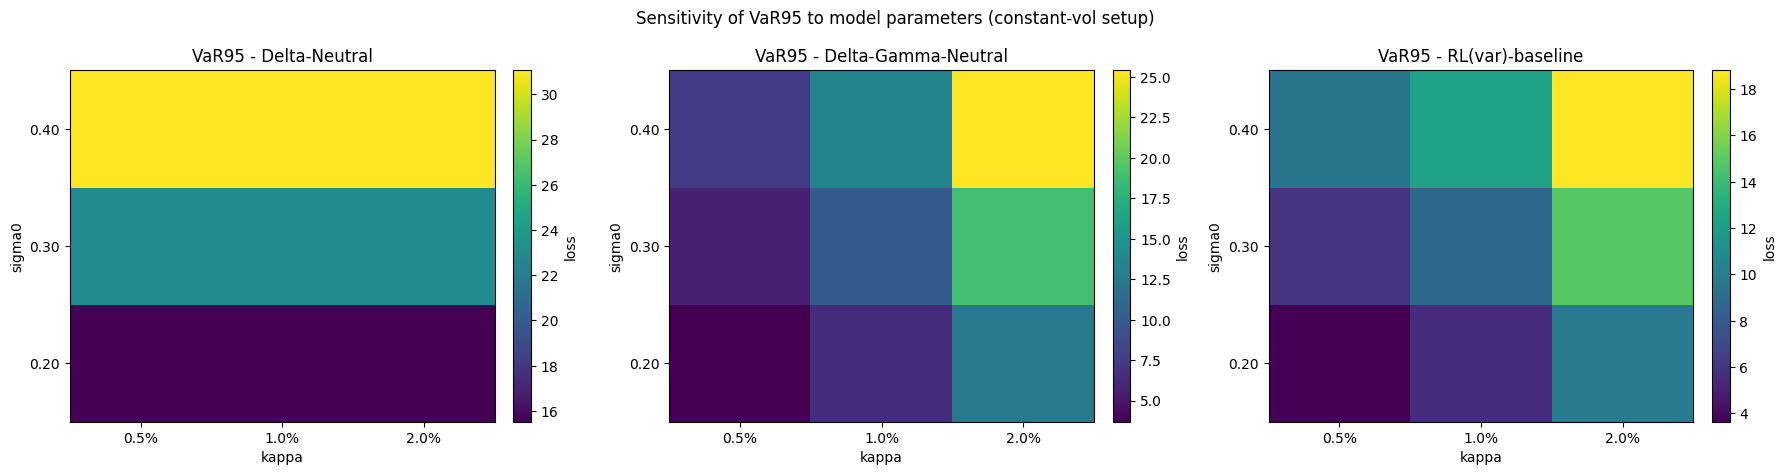

In [29]:
# ------------------------------
# Plot 1/3: VaR95 heatmaps by strategy
# ------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

for ax, strat in zip(axes, STRATEGIES):
    mat = metric_matrix(results, strat, "var95")
    heatmap(ax, mat, f"VaR95 - {strat}", "loss")

plt.suptitle("Sensitivity of VaR95 to model parameters (constant-vol setup)")
plt.tight_layout()
plt.show()



Train baseline RL(var):   0%|          | 0/1 [9:31:22<?, ?it/s]


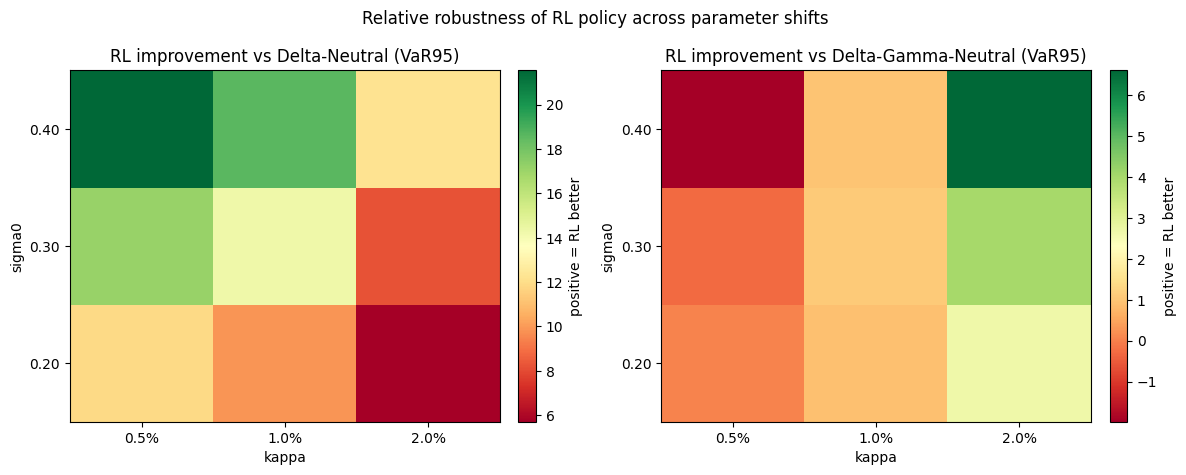

In [30]:
# ------------------------------
# Plot 2/3: RL improvement heatmaps vs benchmarks
# ------------------------------

mat_dn = metric_matrix(results, "Delta-Neutral", "var95")
mat_dg = metric_matrix(results, "Delta-Gamma-Neutral", "var95")
mat_rl = metric_matrix(results, "RL(var)-baseline", "var95")

imp_vs_dn = mat_dn - mat_rl
imp_vs_dg = mat_dg - mat_rl

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

im0 = axes[0].imshow(imp_vs_dn, origin="lower", aspect="auto", cmap="RdYlGn")
axes[0].set_title("RL improvement vs Delta-Neutral (VaR95)")
axes[0].set_xticks(range(len(KAPPA_GRID)))
axes[0].set_xticklabels([f"{100*x:.1f}%" for x in KAPPA_GRID])
axes[0].set_yticks(range(len(SIGMA_GRID)))
axes[0].set_yticklabels([f"{x:.2f}" for x in SIGMA_GRID])
axes[0].set_xlabel("kappa")
axes[0].set_ylabel("sigma0")
cb0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
cb0.set_label("positive = RL better")

im1 = axes[1].imshow(imp_vs_dg, origin="lower", aspect="auto", cmap="RdYlGn")
axes[1].set_title("RL improvement vs Delta-Gamma-Neutral (VaR95)")
axes[1].set_xticks(range(len(KAPPA_GRID)))
axes[1].set_xticklabels([f"{100*x:.1f}%" for x in KAPPA_GRID])
axes[1].set_yticks(range(len(SIGMA_GRID)))
axes[1].set_yticklabels([f"{x:.2f}" for x in SIGMA_GRID])
axes[1].set_xlabel("kappa")
axes[1].set_ylabel("sigma0")
cb1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cb1.set_label("positive = RL better")

plt.suptitle("Relative robustness of RL policy across parameter shifts")
plt.tight_layout()
plt.show()



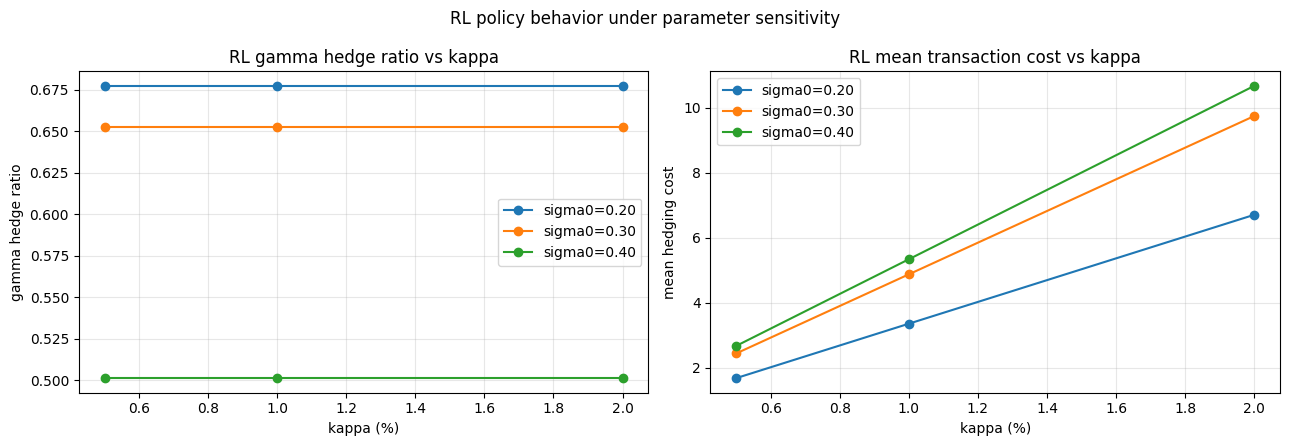

In [31]:
# ------------------------------
# Plot 3/3: RL hedge behavior vs kappa (for each sigma0)
# ------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for sigma0 in SIGMA_GRID:
    xs = []
    ys_ratio = []
    ys_cost = []

    for kappa in KAPPA_GRID:
        row = None
        for r in results:
            if r["strategy"] == "RL(var)-baseline" and np.isclose(r["sigma0"], sigma0) and np.isclose(r["kappa"], kappa):
                row = r
                break
        if row is not None:
            xs.append(100.0 * float(kappa))
            ys_ratio.append(float(row["gamma_hedge_ratio"]))
            ys_cost.append(float(row["mean_cost"]))

    axes[0].plot(xs, ys_ratio, marker="o", label=f"sigma0={sigma0:.2f}")
    axes[1].plot(xs, ys_cost, marker="o", label=f"sigma0={sigma0:.2f}")

axes[0].set_title("RL gamma hedge ratio vs kappa")
axes[0].set_xlabel("kappa (%)")
axes[0].set_ylabel("gamma hedge ratio")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("RL mean transaction cost vs kappa")
axes[1].set_xlabel("kappa (%)")
axes[1].set_ylabel("mean hedging cost")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle("RL policy behavior under parameter sensitivity")
plt.tight_layout()
plt.show()



## Notes for report

- Plot 1 quantifies absolute risk level (VaR95) across parameter shifts.
- Plot 2 highlights where RL keeps (or loses) its edge against rule-based hedges.
- Plot 3 explains *why* by showing how RL adjusts hedge intensity and cost profile.

If you need a stricter runtime budget, reduce:
- `N_EPISODES_RL` (e.g. 300)
- `N_EVAL` (e.g. 1000)
- or the grid size (`SIGMA_GRID`, `KAPPA_GRID`).

